# Clasificacion de gestos de mano con CNN

Este notebook reproduce la parte experimental del articulo:

### Clasificacion de Gestos de Mano Mediante Redes Neuronales Convolucionales y su Aplicacion en Reconocimiento Visual en Tiempo Real.

La meta de esta primera parte es entrenar y evaluar una CNN sobre imagenes estaticas del dataset `LeapGestRecog`. Luego se usará el modelo en una segunda etapa para realizar reconocimiento en tiempo real.

Se usa **PyTorch con CUDA en Windows** porque permite aprovechar directamente la RTX del equipo. La arquitectura, los datos, las metricas y los cuadros siguen el diseno experimental del articulo.


## 1. Preparacion del entorno

Una CNN aprende filtros visuales a partir de muchos ejemplos. Ese entrenamiento requiere muchas multiplicaciones de matrices y convoluciones, por eso conviene usar la GPU. En esta seccion verificamos que PyTorch detecte CUDA y la RTX antes de entrenar.


In [ ]:
from __future__ import annotations

import copy
import math
import random
import re
import shutil
import time
from pathlib import Path
import os

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torchview import draw_graph
from IPython.display import Markdown, display, HTML
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)


In [29]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"
FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"

for directory in [DATA_DIR, RAW_DIR, OUTPUTS_DIR, MODELS_DIR, FIGURES_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SEED = 42
IMAGE_SIZE = (92, 92)  # OpenCV usa (ancho, alto)
BATCH_SIZE = 32
FULL_EPOCHS = 30
SMOKE_TEST_EPOCHS = 1
NUM_WORKERS = 0  # En Windows/Jupyter es mas estable empezar con 0.
KAGGLE_DATASET = "gti-upm/leapgestrecog"

ARTICLE_CLASS_ORDER = [
    "palm", "l", "fist", "fist_moved", "thumb",
    "index", "ok", "palm_moved", "c", "down",
]


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


set_seed(SEED)
PROJECT_ROOT


WindowsPath('c:/Users/jason/OneDrive/Education/0- ULead Ciencia de datos/Materias/6 Cuatrimestre/Mineria de datos/Experimento_Final')

In [28]:
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "PyTorch no detecto CUDA. Revisa que estes usando el kernel "
        "'Python (.venv) - CNN LeapGestRecog' y que PyTorch sea CUDA."
    )

DEVICE = torch.device("cuda")
print(f"GPU: {torch.cuda.get_device_name(0)}")
props = torch.cuda.get_device_properties(0)
print(f"Memoria total aproximada: {props.total_memory / 1024**3:.2f} GB")


PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Memoria total aproximada: 6.00 GB


## 2. Descarga y lectura del dataset

El articulo usa **LeapGestRecog**, un dataset de Kaggle con 20,000 imagenes en escala de grises, 10 clases y 2,000 imagenes por clase.<br>
La estructura separa las imagenes por sujeto y luego por gesto, por ejemplo `00/01_palm/...png`. Por eso buscaremos las imagenes de forma recursiva.


In [ ]:
from dotenv import load_dotenv
import kagglehub

# load .env
load_dotenv()

# set environment variables
os.environ["KAGGLE_USERNAME"] = os.getenv("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = os.getenv("KAGGLE_KEY")

# now kagglehub can authenticate automatically

In [ ]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
KAGGLE_DATASET = "gti-upm/leapgestrecog/versions/1"

def short_path(p: Path) -> str:
    return "..."+"/".join(p.parts[-3:])

def has_images(directory: Path) -> bool:
    image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
    return any(p.suffix.lower() in image_extensions for p in directory.rglob("*"))


def download_dataset_if_needed() -> None:
    if has_images(DATA_DIR):
        print(f"Ya hay imagenes dentro de {short_path(DATA_DIR)}/ No se descargara nuevamente.")
        return

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    kagglehub.dataset_download(KAGGLE_DATASET,output_dir=str(DATA_DIR))
    
    print("Descarga finalizada.")


download_dataset_if_needed()

100%|██████████| 2.13G/2.13G [01:00<00:00, 38.0MB/s]

Extracting files...


Descarga finalizada.


La descarga de Kagglehub por defecto descarga un duplicado de los datos dentro de `...leapgestrecog/leapGestRecog`. Por lo que eliminamos esa carpeta.

In [ ]:
target = DATA_DIR / "leapgestrecog" / "leapGestRecog"

if target.exists():
    shutil.rmtree(target)
    print("Carpeta eliminada:", short_path(target))
else:
    print("La carpeta no existe:", short_path(target))

Carpeta eliminada: ...data/leapgestrecog/leapGestRecog


Verificamos la descarga de los datos

In [18]:
def clean_label(folder_name: str) -> str:
    # Convierte nombres como '01_palm' en 'palm'.
    label = folder_name.strip().lower()
    return re.sub(r"^\d+[_\-\s]*", "", label)


def discover_image_records(root: Path) -> pd.DataFrame:
    image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
    expected = set(ARTICLE_CLASS_ORDER)
    records = []
    for path in sorted(root.rglob("*")):
        if path.suffix.lower() not in image_extensions:
            continue
        label = clean_label(path.parent.name)
        if label not in expected:
            continue
        records.append({"path": str(path), "short_path": short_path(path), "label": label})

    df = pd.DataFrame(records)
    if df.empty:
        raise RuntimeError(
            f"No encontre imagenes con etiquetas esperadas. Revisa la carpeta {short_path(DATA_DIR)}/ o cambia clean_label()."
        )
    return df


df_images = discover_image_records(DATA_DIR)
print("Primeras imagenes detectadas:")
display(df_images[["short_path", "label"]].head())

class_counts = df_images["label"].value_counts().rename_axis("clase").reset_index(name="imagenes")
print("Cantidad de imagenes por clase:")
display(class_counts)

print(f"Total de imagenes detectadas: {len(df_images):,}")
print(f"Total de clases detectadas: {df_images['label'].nunique()}")

detected_classes = set(df_images["label"].unique())
class_names = ARTICLE_CLASS_ORDER if detected_classes == set(ARTICLE_CLASS_ORDER) else sorted(detected_classes)
label_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
print(label_to_idx)

Primeras imagenes detectadas:


,short_path,label
0,...00/01_palm/frame_00_01_0001.png,palm
1,...00/01_palm/frame_00_01_0002.png,palm
2,...00/01_palm/frame_00_01_0003.png,palm
3,...00/01_palm/frame_00_01_0004.png,palm
4,...00/01_palm/frame_00_01_0005.png,palm


Cantidad de imagenes por clase:


,clase,imagenes
0,palm,2000
1,l,2000
2,fist,2000
3,fist_moved,2000
4,thumb,2000
5,index,2000
6,ok,2000
7,palm_moved,2000
8,c,2000
9,down,2000


Total de imagenes detectadas: 20,000
Total de clases detectadas: 10
{'palm': 0, 'l': 1, 'fist': 2, 'fist_moved': 3, 'thumb': 4, 'index': 5, 'ok': 6, 'palm_moved': 7, 'c': 8, 'down': 9}


## 3. Particion 70/15/15

El articulo separa los datos en entrenamiento, validacion y prueba. 
* El modelo aprende los filtros en el entrenamiento.
* La validacion ayuda a elegir el mejor checkpoint.
* La prueba mide el resultado final con datos no vistos.


In [19]:
train_df, temp_df = train_test_split(
    df_images,
    test_size=0.30,
    random_state=SEED,
    stratify=df_images["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

split_summary = pd.DataFrame(
    {
        "particion": ["entrenamiento", "validacion", "prueba"],
        "imagenes": [len(train_df), len(val_df), len(test_df)],
        "porcentaje": [len(train_df) / len(df_images), len(val_df) / len(df_images), len(test_df) / len(df_images)],
    }
)
split_summary["porcentaje"] = (split_summary["porcentaje"] * 100).round(2)
print("Resumen de particiones:")
display(split_summary)

print("Distribucion de clases por particion:")
pd.crosstab(train_df["label"], columns="train").join(
    pd.crosstab(val_df["label"], columns="val")
).join(pd.crosstab(test_df["label"], columns="test"))


Resumen de particiones:


,particion,imagenes,porcentaje
0,entrenamiento,14000,70.0
1,validacion,3000,15.0
2,prueba,3000,15.0


Distribucion de clases por particion:


col_0,train,val,test
label,,,
c,1400,300,300
down,1400,300,300
fist,1400,300,300
fist_moved,1400,300,300
index,1400,300,300
l,1400,300,300
ok,1400,300,300
palm,1400,300,300
palm_moved,1400,300,300


## 4. Preprocesamiento y aumento de datos

Todas las imagens son leidas en escala de grises, se redimensionan a `92 x 92` pixeles y se normalizan al rango `[0, 1]`. <br>
El aumento de datos crea variantes pequeñas de las imagenes de entrenamiento para que la CNN no memorice posiciones exactas.


In [20]:
train_transform = A.Compose(
    [
        A.Affine(
            scale=(0.9, 1.1),
            translate_percent={"x": (-0.10, 0.10), "y": (-0.10, 0.10)},
            rotate=(-20, 20),
            border_mode=cv2.BORDER_REPLICATE,
            p=1.0,
        ),
        A.HorizontalFlip(p=0.5),
        A.ToFloat(max_value=255.0),
    ]
)

eval_transform = A.Compose([A.ToFloat(max_value=255.0)])


class LeapGestureDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, label_to_idx: dict[str, int], transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        image = cv2.imread(row["path"], cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(row["path"])

        image = cv2.resize(image, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
        if self.transform is not None:
            image = self.transform(image=image)["image"]
        else:
            image = image.astype(np.float32) / 255.0

        image = np.expand_dims(image, axis=0).astype(np.float32)
        label = self.label_to_idx[row["label"]]
        return torch.from_numpy(image), torch.tensor(label, dtype=torch.long)


train_dataset = LeapGestureDataset(train_df, label_to_idx, transform=train_transform)
val_dataset = LeapGestureDataset(val_df, label_to_idx, transform=eval_transform)
test_dataset = LeapGestureDataset(test_df, label_to_idx, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

images, labels = next(iter(train_loader))
print(images.shape, labels.shape, images.min().item(), images.max().item())


torch.Size([32, 1, 92, 92]) torch.Size([32]) 0.0117647061124444 0.9843137264251709


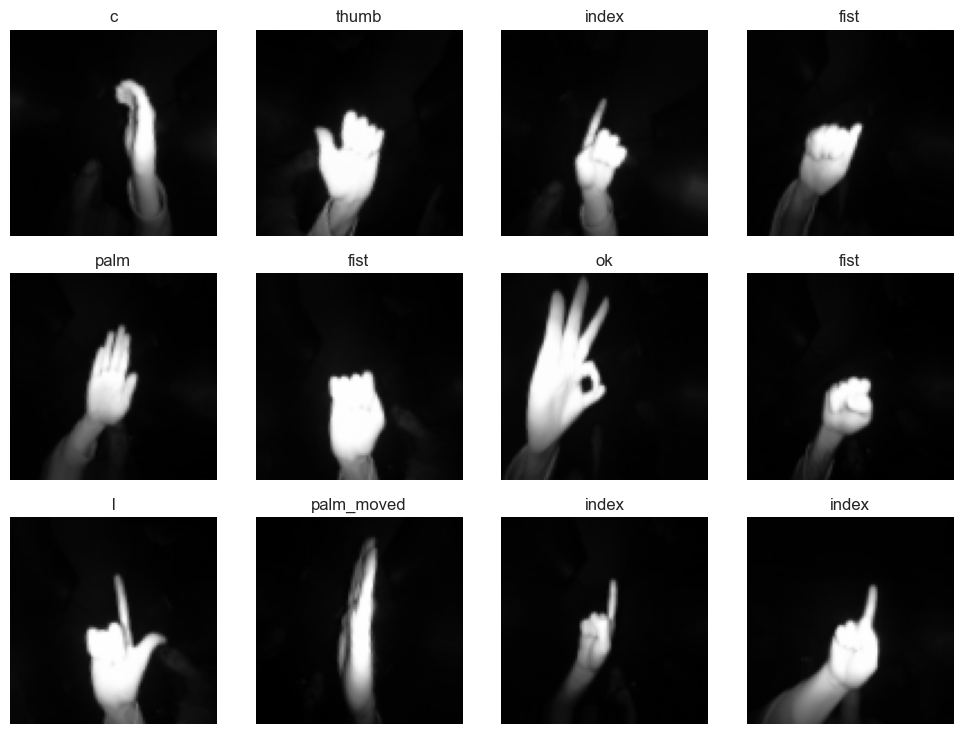

In [21]:
def show_batch(batch_images: torch.Tensor, batch_labels: torch.Tensor, n: int = 12) -> None:
    n = min(n, len(batch_images))
    cols = 4
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(10, 2.5 * rows))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        axes[i].imshow(batch_images[i, 0].numpy(), cmap="gray")
        axes[i].set_title(idx_to_label[int(batch_labels[i])])
        axes[i].axis("off")
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


show_batch(images, labels)


## 5. Arquitecturas evaluadas

- La comparacion busca responder si una red mas profunda y mejor regularizada mejora la clasificacion.
- Batch Normalization ayuda a estabilizar el entrenamiento.
- Dropout fuerza a la red a no depender demasiado de neuronas individuales.


In [65]:
MODEL_CONFIGS = {
    "CNN_A": {
        "dropout": 0.0,
        "blocks": [
            {"out_channels": 32, "convs": 1, "use_bn": False},
            {"out_channels": 64, "convs": 1, "use_bn": False},
            {"out_channels": 128, "convs": 1, "use_bn": False},
        ],
    },
    "CNN_B": {
        "dropout": 0.3,
        "blocks": [
            {"out_channels": 32, "convs": 2, "use_bn": False},
            {"out_channels": 64, "convs": 2, "use_bn": False},
            {"out_channels": 128, "convs": 1, "use_bn": False},
        ],
    },
    "CNN_C": {
        "dropout": 0.4,
        "blocks": [
            {"out_channels": 32, "convs": 2, "use_bn": True},
            {"out_channels": 64, "convs": 2, "use_bn": True},
            {"out_channels": 128, "convs": 1, "use_bn": True},
        ],
    },
}

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, convs: int, use_bn: bool):
        super().__init__()

        layers = []
        for i in range(convs):
            current_in = in_channels if i == 0 else out_channels
            layers.append(nn.Conv2d(current_in, out_channels, kernel_size=3, padding=1))
            if use_bn:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU(inplace=True))

        layers.append(nn.MaxPool2d(kernel_size=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class GestureCNN(nn.Module):
    def __init__(self, model_key: str, num_classes: int):
        super().__init__()
        
        if model_key == "CNN-A":
            dropout = 0.0
            conv_layers = nn.Sequential(
                ConvBlock(1, 32, convs=1, use_bn=False),
                ConvBlock(32, 64, convs=1, use_bn=False),
                ConvBlock(64, 128, convs=1, use_bn=False),
            )
            
        elif model_key == "CNN-B":
            dropout = 0.3
            conv_layers = nn.Sequential(
                ConvBlock(1, 32, convs=2, use_bn=False),
                ConvBlock(32, 64, convs=2, use_bn=False),
                ConvBlock(64, 128, convs=1, use_bn=False),
            )
            
        elif model_key == "CNN-C":
            dropout = 0.4
            conv_layers = nn.Sequential(
                ConvBlock(1, 32, convs=2, use_bn=True),
                ConvBlock(32, 64, convs=2, use_bn=True),
                ConvBlock(64, 128, convs=1, use_bn=True),
            )
        else:
            raise ValueError(f"Modelo desconocido: {model_key}")

        self.model_key = model_key
        self.features = conv_layers
        with torch.no_grad():
            dummy = torch.zeros(1, 1, IMAGE_SIZE[1], IMAGE_SIZE[0])
            flattened = self.features(dummy).view(1, -1).shape[1]

        classifier_layers = [nn.Flatten(), nn.Linear(flattened, 256), nn.ReLU(inplace=True)]
        if dropout > 0:
            classifier_layers.append(nn.Dropout(dropout))
        classifier_layers.append(nn.Linear(256, num_classes))
        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


for model_key in ["CNN-A", "CNN-B", "CNN-C"]:
    model = GestureCNN(model_key, num_classes=len(class_names))
    total_params = sum(param.numel() for param in model.parameters())
    print(f"{model_key}: {total_params:,} parametros")


CNN-A: 4,060,426 parametros
CNN-B: 4,106,602 parametros
CNN-C: 4,107,242 parametros


### Diagramas de las arquitecturas

In [ ]:
def preview_model(
    model,
    image_size: tuple[int, int],
    model_name: str,
    save: bool = False,
    output_dir: str = "model_diagrams",
):
    if save:
        Path(output_dir).mkdir(parents=True, exist_ok=True)

    graph = draw_graph(
        model,
        input_size=(1, 1, image_size[1], image_size[0]),
        expand_nested=True,
        graph_name=model_name,
        save_graph=save,
        directory=output_dir if save else None,
        filename=model_name if save else None,
    )

    if save:
        print(f"Diagrama guardado en: {Path(output_dir) / (model_name + '.png')}")

    return graph


graphs = []

for model_key in ["CNN-A", "CNN-B", "CNN-C"]:
    model = GestureCNN(model_key, num_classes=len(class_names))
    graph = preview_model(model, IMAGE_SIZE, model_key)
    svg = graph.visual_graph.pipe(format="svg").decode("utf-8")
    graphs.append((model_key, svg))

html = '<div style="display:flex; gap:30px;">'

for name, svg in graphs:
    html += f"""
        <div style="text-align:center">
            <h3>{name}</h3>
            {svg}
        </div>
    """

html += "</div>"

display(HTML(html))


(process:20788): Pango-WARNING **: 09:09:54.248: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

(process:10464): Pango-WARNING **: 09:09:54.733: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

(process:31048): Pango-WARNING **: 09:09:55.231: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


## 6. Entrenamiento

1. Primero se corre una prueba de una epoca para confirmar que el pipeline funciona.
2. Despues se entrenan los tres modelos por 30 epocas.
3. El mejor checkpoint de cada modelo se guarda segun accuracy de validacion.


In [42]:
def train_one_epoch(model: nn.Module, loader: DataLoader, criterion, optimizer) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, targets in loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        total += batch_size

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, criterion) -> dict:
    model.eval()
    total_loss = 0.0
    total = 0
    y_true = []
    y_pred = []

    for images, targets in loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, targets)

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total += batch_size
        y_true.extend(targets.cpu().numpy().tolist())
        y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

    return {
        "loss": total_loss / total,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }


class TrainingMonitor:
    def __init__(self, model_keys: list[str], epochs: int):
        self.epochs = epochs
        self.rows = {
            model_key: {
                "model": model_key,
                "progress": "0 / {}".format(epochs),
                "pct": "0%",
                "train_acc": "",
                "val_acc": "",
                "val_loss": "",
                "lr": "",
                "status": "pending",
            }
            for model_key in model_keys
        }
        self.handle = display(HTML(self._render()), display_id=True)

    def update(
        self,
        model_key: str,
        epoch: int,
        train_acc: float | None = None,
        val_acc: float | None = None,
        val_loss: float | None = None,
        lr: float | None = None,
        status: str = "training",
    ) -> None:
        pct = int((epoch / self.epochs) * 100)

        self.rows[model_key]["progress"] = f"{epoch} / {self.epochs}"
        self.rows[model_key]["pct"] = f"{pct}%"
        self.rows[model_key]["train_acc"] = f"{train_acc:.4f}" if train_acc is not None else ""
        self.rows[model_key]["val_acc"] = f"{val_acc:.4f}" if val_acc is not None else ""
        self.rows[model_key]["val_loss"] = f"{val_loss:.4f}" if val_loss is not None else ""
        self.rows[model_key]["lr"] = f"{lr:.2e}" if lr is not None else ""
        self.rows[model_key]["status"] = status

        self.handle.update(HTML(self._render()))

    def finish(self, model_key: str, best_val_acc: float, elapsed_seconds: float) -> None:
        self.rows[model_key]["status"] = f"done | best_val={best_val_acc:.4f} | {elapsed_seconds / 60:.1f} min"
        self.handle.update(HTML(self._render()))

    def _render(self) -> str:
        df = pd.DataFrame(self.rows.values())
        return df.to_html(index=False)


def train_model(
    model_key: str,
    monitor: TrainingMonitor | None = None,
    epochs: int = FULL_EPOCHS,
) -> tuple[nn.Module, pd.DataFrame, Path]:
    set_seed(SEED)    
    # print(f"{model_key} | initializing model...")
    model = GestureCNN(model_key, num_classes=len(class_names)).to(DEVICE)   
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )
    checkpoint_path = MODELS_DIR / f"{model_key.lower()}_best.pt"

    history = []
    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())
    start_time = time.time()

    # print(f"{model_key} | starting training...")
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate_model(model, val_loader, criterion)
        scheduler.step(val_metrics["loss"])

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "model": model_key,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_macro": val_metrics["f1_macro"],
            "learning_rate": current_lr,
        }
        history.append(row)

        if monitor is not None:
            monitor.update(
                model_key=model_key,
                epoch=epoch,
                train_acc=train_acc,
                val_acc=val_metrics["accuracy"],
                val_loss=val_metrics["loss"],
                lr=current_lr,
                status="training",
            )
        else:
            pct = int((epoch / epochs) * 100)
            print(
                f"{model_key} | {epoch} / {epochs} ({pct}%) | "
                f"train_acc={train_acc:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} | lr={current_lr:.2e}"
            )

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_key": model_key,
                    "class_names": class_names,
                    "label_to_idx": label_to_idx,
                    "image_size": IMAGE_SIZE,
                    "state_dict": best_state,
                    "best_val_accuracy": best_val_acc,
                },
                checkpoint_path,
            )

    model.load_state_dict(best_state)
    elapsed = time.time() - start_time

    if monitor is not None:
        monitor.finish(model_key, best_val_acc, elapsed)
    else:
        print(f"{model_key} done | best_val={best_val_acc:.4f} | {elapsed / 60:.1f} min")

    return model, pd.DataFrame(history), checkpoint_path

In [43]:
# Prueba rapida: si esto funciona, el dataset, la GPU y la arquitectura estan conectados.
smoke_model, smoke_history, _ = train_model("CNN-A", epochs=SMOKE_TEST_EPOCHS)
display(smoke_history)

CNN-A | 1 / 1 (100%) | train_acc=0.6192 | val_acc=0.9523 | val_loss=0.1685 | lr=1.00e-03
CNN-A done | best_val=0.9523 | 0.7 min


,model,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_f1_macro,learning_rate
0,CNN-A,1,1.061876,0.619214,0.16848,0.952333,0.952842,0.001


In [44]:
# Entrenamiento completo del experimento.
monitor = TrainingMonitor(model_keys=["CNN-A", "CNN-B", "CNN-C"], epochs=FULL_EPOCHS)

trained_models = {}
histories = {}
checkpoints = {}

for model_key in ["CNN-A", "CNN-B", "CNN-C"]:
    model, history, checkpoint_path = train_model(model_key, epochs=FULL_EPOCHS, monitor=monitor)
    trained_models[model_key] = model
    histories[model_key] = history
    checkpoints[model_key] = checkpoint_path
    history.to_csv(REPORTS_DIR / f"historia_{model_key.lower()}.csv", index=False)


model,progress,pct,train_acc,val_acc,val_loss,lr,status
CNN-A,30 / 30,100%,0.9988,0.9990,0.0026,1.25e-04,done | best_val=1.0000 | 24.1 min
CNN-B,30 / 30,100%,0.9961,1.0000,0.0004,5.00e-04,done | best_val=1.0000 | 25.8 min
CNN-C,30 / 30,100%,0.9931,1.0000,0.0001,5.00e-04,done | best_val=1.0000 | 26.0 min


## 7. Evaluacion y cuadros de resultados

En esta parte se evalua cada modelo sobre el conjunto de prueba. Los valores del articulo se muestran como referencia, pero los cuadros principales usan los resultados reales que produzca tu ejecucion.


In [45]:
def load_checkpoint(model_key: str) -> nn.Module:
    checkpoint_path = MODELS_DIR / f"{model_key.lower()}_best.pt"
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model = GestureCNN(model_key, num_classes=len(class_names)).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    return model


criterion = nn.CrossEntropyLoss()
model_results = []
test_predictions = {}

for model_key in ["CNN-A", "CNN-B", "CNN-C"]:
    model = trained_models[model_key] if model_key in trained_models else load_checkpoint(model_key)
    val_metrics = evaluate_model(model, val_loader, criterion)
    test_metrics = evaluate_model(model, test_loader, criterion)
    test_predictions[model_key] = test_metrics
    model_results.append(
        {
            "Modelo": model_key,
            "Acc. Val.": val_metrics["accuracy"],
            "Acc. Test": test_metrics["accuracy"],
            "F1-macro": test_metrics["f1_macro"],
            "Loss": test_metrics["loss"],
        }
    )

model_results_df = pd.DataFrame(model_results)
model_results_df.to_csv(REPORTS_DIR / "resultados_modelos_obtenidos.csv", index=False)

cuadro_iii = model_results_df.copy()
for column in ["Acc. Val.", "Acc. Test", "F1-macro"]:
    cuadro_iii[column] = (cuadro_iii[column] * 100).round(2).astype(str) + " %"
cuadro_iii["Loss"] = cuadro_iii["Loss"].round(4)

display(Markdown("### Cuadro III. Comparacion de modelos en la particion de prueba"))
display(cuadro_iii)


### Cuadro III. Comparacion de modelos en la particion de prueba

,Modelo,Acc. Val.,Acc. Test,F1-macro,Loss
0,CNN-A,100.0 %,99.97 %,99.97 %,0.0017
1,CNN-B,100.0 %,99.97 %,99.97 %,0.0017
2,CNN-C,100.0 %,99.9 %,99.9 %,0.0061


Creamos una lista ordenada para rankear los modelos de mejor a peor

In [52]:
model_ranking = (
    model_results_df
    .sort_values(
        by=["F1-macro", "Acc. Test", "Loss"],
        ascending=[False, False, True],
    )["Modelo"]
    .tolist()
)

print("Ranking (best → worst):")
for i, model in enumerate(model_ranking, 1):
    print(f"{i}. {model}")
    
best_model_key = model_ranking[0]
print("\nMejor modelo:", best_model_key)

Ranking (best → worst):
1. CNN-B
2. CNN-A
3. CNN-C

Mejor modelo: CNN-B


In [57]:
best_cnn_metrics = test_predictions[best_model_key]
report = classification_report(
    best_cnn_metrics["y_true"],
    best_cnn_metrics["y_pred"],
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

class_rows = []
for class_name in class_names:
    class_rows.append(
        {
            "Clase": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1": report[class_name]["f1-score"],
        }
    )
class_rows.append(
    {
        "Clase": "Macro avg",
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1": report["macro avg"]["f1-score"],
    }
)

cuadro_iv_numeric = pd.DataFrame(class_rows)
cuadro_iv_numeric.to_csv(REPORTS_DIR / "cuadro_iv_metricas_por_clase_cnn_c_obtenidas.csv", index=False)

cuadro_iv = cuadro_iv_numeric.copy()
for column in ["Precision", "Recall", "F1"]:
    cuadro_iv[column] = (cuadro_iv[column] * 100).round(2).astype(str) + " %"

display(Markdown(f"### Cuadro IV. Metricas por clase - modelo {best_model_key}"))
display(cuadro_iv)

### Cuadro IV. Metricas por clase - modelo CNN-B

,Clase,Precision,Recall,F1
0,palm,100.0 %,99.67 %,99.83 %
1,l,100.0 %,100.0 %,100.0 %
2,fist,99.67 %,100.0 %,99.83 %
3,fist_moved,100.0 %,100.0 %,100.0 %
4,thumb,100.0 %,100.0 %,100.0 %
5,index,100.0 %,100.0 %,100.0 %
6,ok,100.0 %,100.0 %,100.0 %
7,palm_moved,100.0 %,100.0 %,100.0 %
8,c,100.0 %,100.0 %,100.0 %
9,down,100.0 %,100.0 %,100.0 %


## 8. Curvas y matriz de confusion

Las curvas muestran si el modelo aprende de forma estable. Una brecha muy grande entre entrenamiento y validacion suele indicar sobreajuste: el modelo memoriza el entrenamiento, pero no generaliza igual de bien.


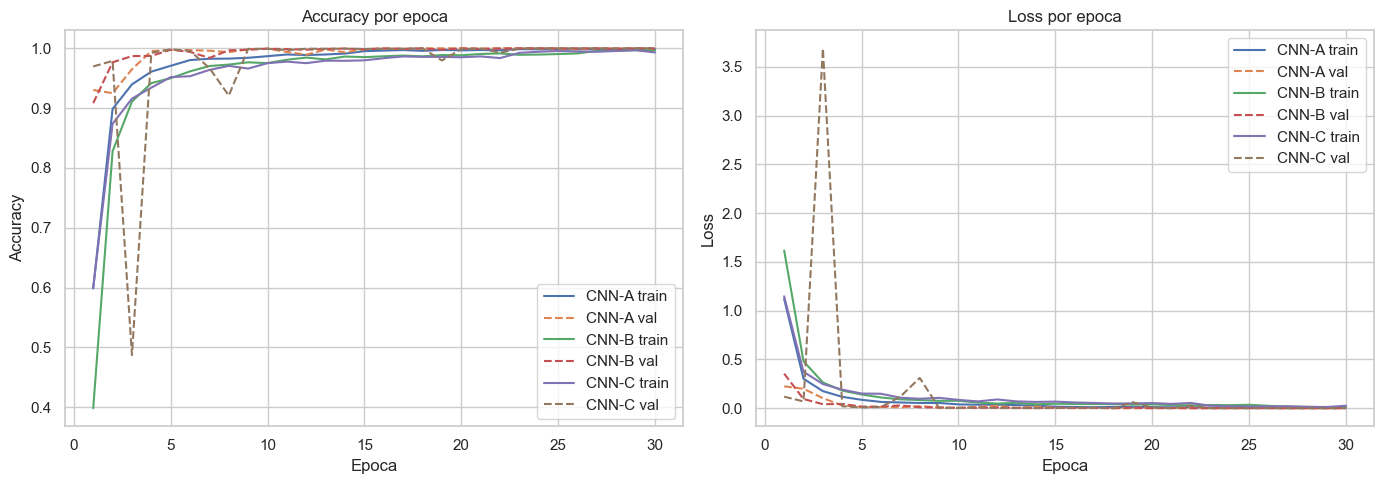

In [58]:
if histories:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model_key, history in histories.items():
        axes[0].plot(history["epoch"], history["train_accuracy"], label=f"{model_key} train")
        axes[0].plot(history["epoch"], history["val_accuracy"], linestyle="--", label=f"{model_key} val")
        axes[1].plot(history["epoch"], history["train_loss"], label=f"{model_key} train")
        axes[1].plot(history["epoch"], history["val_loss"], linestyle="--", label=f"{model_key} val")

    axes[0].set_title("Accuracy por epoca")
    axes[0].set_xlabel("Epoca")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[1].set_title("Loss por epoca")
    axes[1].set_xlabel("Epoca")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "curvas_aprendizaje_modelos.png", dpi=160)
    plt.show()
else:
    print("No hay historiales en memoria. Ejecuta el entrenamiento completo para generar curvas.")


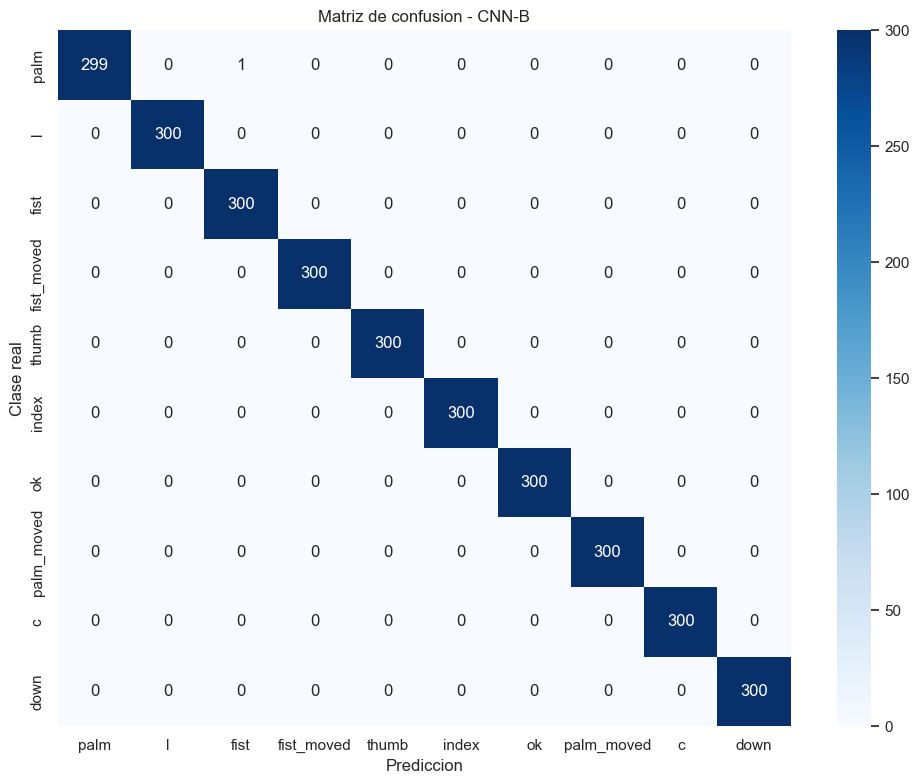

In [59]:
cm = confusion_matrix(best_cnn_metrics["y_true"], best_cnn_metrics["y_pred"])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Matriz de confusion - {best_model_key}")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"matriz_confusion_{best_model_key.lower().replace('-', '_')}.png", dpi=160)
plt.show()

## 9. Exportacion para la segunda parte

El reconocimiento en tiempo real no se realiza en este notebook. <br>
Lo que si dejamos listo es el checkpoint del mejor modelo para cargarlo despues desde OpenCV u otra interfaz de camara.


In [64]:
best_checkpoint = MODELS_DIR / f"{best_model_key.lower()}_best.pt"

if best_checkpoint.exists():
    export_path = MODELS_DIR / f"gesture_recognition_({best_model_key.lower().replace('-', '_')}).pt"
    shutil.copy2(best_checkpoint, export_path)
    print(f"Modelo {best_model_key} exportado para la segunda parte: {short_path(export_path)}")
else:
    print(f"Aun no existe el checkpoint de {best_model_key}. Ejecuta el entrenamiento completo primero.")


Modelo CNN-B exportado para la segunda parte: ...outputs/models/gesture_recognition_(cnn_b).pt


## 10. Cierre

Al finalizar, revisa:

- `outputs/models/`: checkpoints de los modelos.
- `outputs/reports/`: CSV con los cuadros generados.
- `outputs/figures/`: curvas de aprendizaje y matriz de confusion.

Para la segunda parte, el siguiente paso sera cargar `cnn_c_para_reconocimiento_tiempo_real.pt`, capturar una region de interes de la camara, aplicar el mismo preprocesamiento `64 x 64` grayscale y hacer inferencia cuadro por cuadro.
